# Introduction to vector databases on S&P 500 news

**Deliverable:** `news_vector_store_sp500_holguin_A01797412`

**Author:** Erick Holguín Pardavell

# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Load and Explore Financial News Data:**
   - Load a preprocessed dataset of financial news headlines and summaries related to S&P 500 companies.
   - Inspect and structure relevant metadata including publication date, ticker, and provider.

2. **Build a Custom Vector Store:**
   - Combine title and summary text for embedding.
   - Implement a vector store from scratch with support for semantic search and optional metadata-based filtering using cosine similarity.

3. **Generate and Use Sentence Embeddings:**
   - Apply a pre-trained transformer model (all-MiniLM-L6-v2) to encode text into embeddings for semantic analysis.

4. **Perform Semantic Search with Filtering:**
   - Retrieve the most relevant news documents for a given query using both full-dataset and metadata-filtered searches.

5. **Analyze Semantic Search Results:**
   - Interpret and visualize results of search queries (e.g., "AI announcement").
   - Identify temporal patterns and ticker frequency among top-ranked results.

6. **Implement a FAISS-Based Vector Store:**
   - Normalize embeddings and use FAISS (IndexFlatIP) to enable efficient similarity search at scale.
   - Compare FAISS-based search results with custom vector store results.

7. **Critically Compare Search Systems:**
   - Evaluate differences in similarity computation, speed, and scalability between custom and FAISS-based systems.
   - Reflect on design trade-offs for real-world vector search systems.

## Install and Import important librairies

In [1]:
%pip install -q sentence-transformers
%pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 65.8 MB/s eta 0:00:00


In [2]:
from sentence_transformers import SentenceTransformer
import faiss
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import matplotlib.pyplot as plt

from typing import Callable, Optional

# Single-hue chart style: one color for magnitude, recessive grid.
CHART_BLUE = "#4269D0"
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})

## Load news data

Load the provided news dataset and inspect the contents.

👉 **Instructions**:
- Load the CSV file named df_news.csv into a pandas DataFrame.
- Convert the PUBLICATION_DATE column to a proper date format (not datetime).
- Display the first few rows to understand the data structure. The key columns you'll be using are:
  - TITLE
  - SUMMARY
  - TICKER
  - PROVIDER
  - PUBLICATION_DATE

In [4]:
df_news = pd.read_csv('df_news.csv')

# Convert to a plain date (not a full datetime with time and timezone)
df_news['PUBLICATION_DATE'] = pd.to_datetime(df_news['PUBLICATION_DATE']).dt.date

display(df_news)

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19,StockStory,https://finance.yahoo.com/news/3-cash-producin...
...,...,...,...,...,...,...
2449,IP,3 Companies Estimated To Be Trading Below Intr...,The United States market has shown robust perf...,2025-05-13,Simply Wall St.,https://finance.yahoo.com/news/3-companies-est...
2450,IPG,"Booz Allen's Q4 Earnings Surpass Estimates, In...",BAH's fourth-quarter fiscal 2025 earnings incr...,2025-05-27,Zacks,https://finance.yahoo.com/news/booz-allens-q4-...
2451,IPG,Buyout Strategy & Strong Liquidity Aid IPG Des...,Interpublic Group's acquisitions and strong li...,2025-05-27,Zacks,https://finance.yahoo.com/news/buyout-strategy...
2452,IPG,Q1 Earnings Outperformers: Interpublic Group (...,Let’s dig into the relative performance of Int...,2025-05-27,StockStory,https://finance.yahoo.com/news/q1-earnings-out...


### Cleaning and exploring the key metadata

Before embedding anything, we check data quality (nulls, duplicates) and get a feel
for the metadata we will later use for filtering and analysis: `TICKER`, `PROVIDER`
and `PUBLICATION_DATE`. Following the Part 1 feedback, `PROVIDER` is now part of the
exploration, and we deduplicate syndicated stories by `URL`.

In [5]:
print("Shape:", df_news.shape)
print("\nNull values per column:")
print(df_news.isna().sum())

print("\nDuplicated URLs (syndicated stories):", df_news.duplicated(subset='URL').sum())
print("Duplicated TITLE+SUMMARY pairs:", df_news.duplicated(subset=['TITLE', 'SUMMARY']).sum())

Shape: (2454, 6)

Null values per column:
TICKER              0
TITLE               0
SUMMARY             0
PUBLICATION_DATE    1
PROVIDER            1
URL                 1
dtype: int64

Duplicated URLs (syndicated stories): 184
Duplicated TITLE+SUMMARY pairs: 194


In [6]:
# Deduplicate syndicated stories by URL (keep the first occurrence).
# The same wire story republished under several tickers would otherwise dominate
# nearest-neighbour lists with identical texts.
n_before = len(df_news)
df_news = df_news.drop_duplicates(subset='URL', keep='first').reset_index(drop=True)
print(f"Rows: {n_before} -> {len(df_news)} after URL deduplication")

Rows: 2454 -> 2270 after URL deduplication


In [8]:
print("Unique tickers:", df_news['TICKER'].nunique())

print("\nArticles per ticker (top 10):")
display(df_news['TICKER'].value_counts().head(10).to_frame('articles'))

print("Unique providers:", df_news['PROVIDER'].nunique())
print("\nArticles per provider (top 10):")
display(df_news['PROVIDER'].value_counts().head(10).to_frame('articles'))

Unique tickers: 247

Articles per ticker (top 10):


,articles
TICKER,
MMM,10
AOS,10
ABT,10
ABBV,10
ACN,10
ADBE,10
AMD,10
AES,10
AFL,10


Unique providers: 81

Articles per provider (top 10):


,articles
PROVIDER,
Zacks,686
Simply Wall St.,410
StockStory,243
Insider Monkey,207
Motley Fool,109
GuruFocus.com,85
TipRanks,48
Investor's Business Daily,47
Bloomberg,38


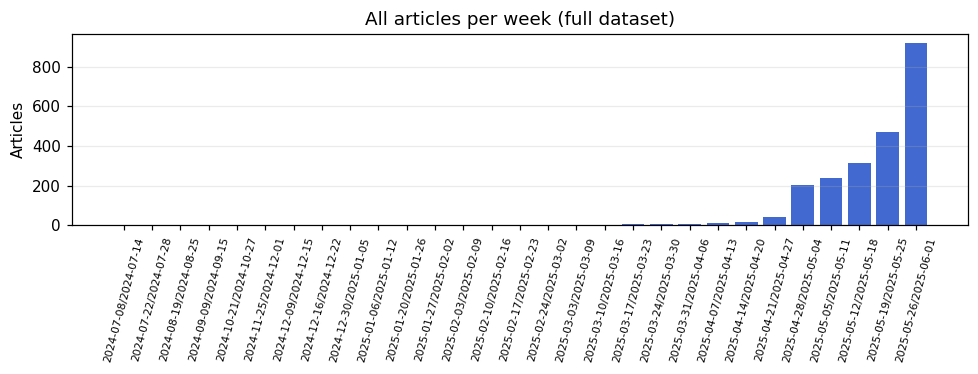

In [9]:
# Overall temporal distribution of the full dataset (for later comparison with
# the distribution of the top-50 'AI announcement' results).
dates_all = pd.to_datetime(df_news['PUBLICATION_DATE'].astype(str))
weekly_all = dates_all.dt.to_period('W').value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(weekly_all.index.astype(str), weekly_all.values, color=CHART_BLUE)
ax.set_title('All articles per week (full dataset)')
ax.set_ylabel('Articles')
ax.tick_params(axis='x', rotation=75, labelsize=7)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

## Implement custom vector store

You will now implement a basic vector store from scratch. This class will allow you to:
1. Store embedded text and metadata.
2. Perform filtered semantic search using cosine similarity.

👉 **Instructions**:

### Step 1: Prepare Documents
- Combine the TITLE and SUMMARY columns into a single column named EMBEDDED_TEXT.
- This combined text will be embedded later.

### Step 2: Load Embedding Model
- Load the 'all-MiniLM-L6-v2' model from sentence-transformers.

### Step 3: Define CustomVectorStore Class
Implement the class with the following methods (functions):

- '__init__': Accepts an embedding model, list of documents, and corresponding metadata. Computes and stores embeddings for all documents.
- search: Takes a query and returns the top k most similar documents, optionally filtered using metadata.
  - If a metadata_filter function is provided, apply it before computing similarity.
  - Use cosine similarity to compute distances.
  - Return the top k results as tuples of: (document, metadata, similarity score).

✅ **Requirements**:
- Ensure the number of documents matches the number of metadata entries.
- Make use of sklearn.metrics.pairwise.cosine_similarity.

You will test your class at the end.

In [10]:
# Step 1: combine TITLE and SUMMARY into a single text field for embedding
df_news['EMBEDDED_TEXT'] = df_news['TITLE'].astype(str) + '. ' + df_news['SUMMARY'].astype(str)
display(df_news[['TICKER', 'EMBEDDED_TEXT']].head())

,TICKER,EMBEDDED_TEXT
0,MMM,2 Dow Jones Stocks with Promising Prospects an...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice. The S&P ...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...


In [11]:
# Step 2: load the sentence-transformers model
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')
print('Embedding dimension:', model_minilm.encode(['test sentence']).shape[1])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384


In [12]:
# Step 3: the custom vector store
class CustomVectorStore:
    """Minimal in-memory vector store with cosine-similarity semantic search.

    Embeddings are computed once at construction time; every search encodes only
    the query and compares it against the stored matrix with
    sklearn's cosine_similarity (a full brute-force scan).
    """

    def __init__(self, embedding_model: SentenceTransformer,
                 documents: list[str], metadata: list[dict]) -> None:
        if len(documents) != len(metadata):
            raise ValueError(
                f'documents ({len(documents)}) and metadata ({len(metadata)}) '
                'must have the same length'
            )
        self.embedding_model = embedding_model
        self.documents = list(documents)
        self.metadata = list(metadata)
        self.embeddings = embedding_model.encode(documents, show_progress_bar=True)

    def search(self, query: str, k: int = 5,
               metadata_filter: Optional[Callable[[dict], bool]] = None
               ) -> list[tuple[str, dict, float]]:
        """Return the top-k (document, metadata, cosine similarity) tuples.

        If metadata_filter is given, it is applied BEFORE computing similarity,
        so only the rows that pass the filter are scored.
        """
        query_embedding = self.embedding_model.encode([query])

        if metadata_filter is not None:
            candidate_idx = [i for i, m in enumerate(self.metadata) if metadata_filter(m)]
        else:
            candidate_idx = list(range(len(self.documents)))

        if not candidate_idx:
            return []

        similarities = cosine_similarity(query_embedding, self.embeddings[candidate_idx])[0]
        top_local = np.argsort(similarities)[::-1][:k]

        return [
            (self.documents[candidate_idx[i]],
             self.metadata[candidate_idx[i]],
             float(similarities[i]))
            for i in top_local
        ]

## Create and populate the vector store

👉 **Instructions**:
- Convert the combined EMBEDDED_TEXT column into a list of strings.
- Create a metadata list of dictionaries for each document with keys:
  - 'PUBLICATION_DATE'
  - 'TICKER'
  - 'PROVIDER'
- Instantiate your CustomVectorStore using:
  - The embedding model.
  - The list of document strings.
  - The metadata list.

After initializing the store, you should be able to perform searches using:
'store.search("Apple earnings", k=3)'

In [13]:
documents = df_news['EMBEDDED_TEXT'].tolist()
metadata = df_news[['PUBLICATION_DATE', 'TICKER', 'PROVIDER']].to_dict('records')

store = CustomVectorStore(model_minilm, documents, metadata)
print('Documents in store:', len(store.documents))
print('Embeddings matrix shape:', store.embeddings.shape)

Batches:   0%|          | 0/71 [00:00<?, ?it/s]

Documents in store: 2270
Embeddings matrix shape: (2270, 384)


In [14]:
# Helper: turn a list of (document, metadata, score) tuples into a tidy DataFrame
def results_to_df(results: list[tuple[str, dict, float]]) -> pd.DataFrame:
    """Render search results as a DataFrame for display."""
    return pd.DataFrame([
        {
            'TICKER': meta_['TICKER'],
            'PUBLICATION_DATE': meta_['PUBLICATION_DATE'],
            'PROVIDER': meta_['PROVIDER'],
            'SIMILARITY': round(score, 4),
            'DOCUMENT': doc,
        }
        for doc, meta_, score in results
    ])

# Quick sanity test
display(results_to_df(store.search('Apple earnings', k=3)))

,TICKER,PUBLICATION_DATE,PROVIDER,SIMILARITY,DOCUMENT
0,HUM,2025-05-28,Simply Wall St.,0.5784,Humana (NYSE:HUM) Sees Revenue Increase in Fir...
1,APTV,2025-05-01,Barrons.com,0.5654,"Aptiv Stock Rises. Earnings Were Great, But Ta..."
2,CAT,2025-05-30,Zacks,0.5543,Why Is Caterpillar (CAT) Up 12.1% Since Last E...


In [15]:
# Test the optional metadata filter: same query restricted to a single ticker
apple_only = store.search(
    'quarterly earnings results',
    k=3,
    metadata_filter=lambda m: m['TICKER'] == 'AAPL',
)
display(results_to_df(apple_only))

,TICKER,PUBLICATION_DATE,PROVIDER,SIMILARITY,DOCUMENT
0,AAPL,2025-05-31,Investopedia,0.2706,These Are Stocks You Should Watch in June. Sto...
1,AAPL,2025-05-31,Motley Fool,0.2230,Warren Buffett Holds Apple Stock Despite Tarif...
2,AAPL,2025-05-31,Motley Fool,0.1617,Best Stock to Buy Right Now: Apple vs. Chipotl...


## Using your vector store and analyzing the results

### Retrieve AI Announcements

Now that your vector store is working, let's use it to retrieve relevant documents.

👉 **Instructions**:
- Perform a semantic search using the query `"AI announcement"` with `k=50` to retrieve the top 50 most relevant articles.
- Display each result's:
  - `TICKER`
  - `PUBLICATION_DATE`
  - `PROVIDER`
  - Similarity score
  - Full document text

In [16]:
ai_results = store.search('AI announcement', k=50)
df_ai = results_to_df(ai_results)

pd.set_option('display.max_colwidth', 250)
display(df_ai)

,TICKER,PUBLICATION_DATE,PROVIDER,SIMILARITY,DOCUMENT
0,ADBE,2025-05-27,Investor's Business Daily,0.5518,"AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus.. Amid hype over artificial intelligence, the best AI stocks generate revenue or get a strategic edge from the fast evolving technology."
1,CEG,2025-05-28,Yahoo Finance Video,0.5006,"Nvidia earnings: Its AI performance could lift these stocks. Ahead of Nvidia's first quarter earnings report, Rational Equity Armor Fund portfolio manager Joe Tigay joins Morning Brief with Brad Smith and Madison Mills to discuss which artificial..."
2,BKR,2025-05-29,Investopedia,0.4955,"C3.ai Stock Soars as Firm Posts Strong Results, Renews Major Contract. C3.ai reported a lower loss and higher revenue than analysts estimated on growing demand for generative AI products."
3,GOOGL,2025-05-31,TechCrunch,0.4843,"Google quietly released an app that lets you download and run AI models locally. Last week, Google quietly released an app that lets users run a range of openly available AI models from the AI dev platform Hugging Face on their phones. Called Goo..."
4,AMZN,2025-05-30,Bloomberg,0.4838,"Amazon's AI Roadmap With AWS CEO Garman. Every aspect of Amazon is leveraging artificial intelligence, says Matt Garman, CEO of Amazon Web Services. Garman discusses Amazon's AI roadmap and reflects on his first year in the role with Ed Ludlow on..."
5,AMD,2025-05-30,Simply Wall St.,0.4700,"This Week In AI Chips - Accelerating In-Car AI: Cerence Partners With Arm. Cerence AI has entered into a strategic partnership with Arm to enhance the capabilities and performance of its CaLLM Edge, an embedded small language model, by utilizing ..."
6,BKR,2025-05-29,Insider Monkey,0.4691,"C3 AI and Baker Hughes Extend Joint Venture Through 2028. C3.ai, Inc. (NYSE:AI) and Baker Hughes have renewed and expanded their joint venture agreement. In a statement on May 28, 2025, C3 AI said that the joint venture, established in 2019 to de..."
7,EXPE,2025-05-15,Marketing Dive,0.4661,Expedia brings generative AI trip-planning tool to Instagram. The travel company is also expanding its search and discovery capabilities by integrating with OpenAI Operator and Microsoft Copilot Actions.
8,ABNB,2025-05-23,Motley Fool,0.4586,"Got $3,000? 3 Artificial Intelligence (AI) Stocks to Buy and Hold for the Long Term.. This travel technology company can drive investor returns through AI-driven decision-making. When taking these factors into account, investors may want to cons..."
9,AMZN,2025-05-30,Investor's Business Daily,0.4355,"ServiceNow Regenerates On Swarm Of AI Deals With Amazon, Microsoft And More. Teaming up with AI giants like Amazon, Microsoft and others, ServiceNow stock has rebounded and stands poised to break out."


### **Q1.** What are the top companies (by TICKER) most frequently appearing in the top 50 search results for the query "AI announcement"?
Check their company names on Yahoo Finance. Are you surprised by the results?

✅ **Your task**:
- Count the number of times each TICKER appears.
- Print and analyze the top results.

In [17]:
ticker_counts = Counter(df_ai['TICKER'])
print('Ticker frequency in the top 50 results:')
for ticker, count in ticker_counts.most_common():
    print(f'  {ticker}: {count}')

Ticker frequency in the top 50 results:
  AMD: 5
  BKR: 3
  CTSH: 3
  AMZN: 2
  EXPE: 2
  ABNB: 2
  IT: 2
  INTC: 2
  EA: 2
  IEX: 2
  ADBE: 1
  CEG: 1
  GOOGL: 1
  DELL: 1
  GOOG: 1
  FFIV: 1
  AVGO: 1
  KMX: 1
  HPE: 1
  ACN: 1
  SCHW: 1
  APTV: 1
  AME: 1
  DHR: 1
  ANET: 1
  APH: 1
  HPQ: 1
  ADSK: 1
  IDXX: 1
  AEE: 1
  APO: 1
  GEHC: 1
  HD: 1
  AKAM: 1
  EMR: 1


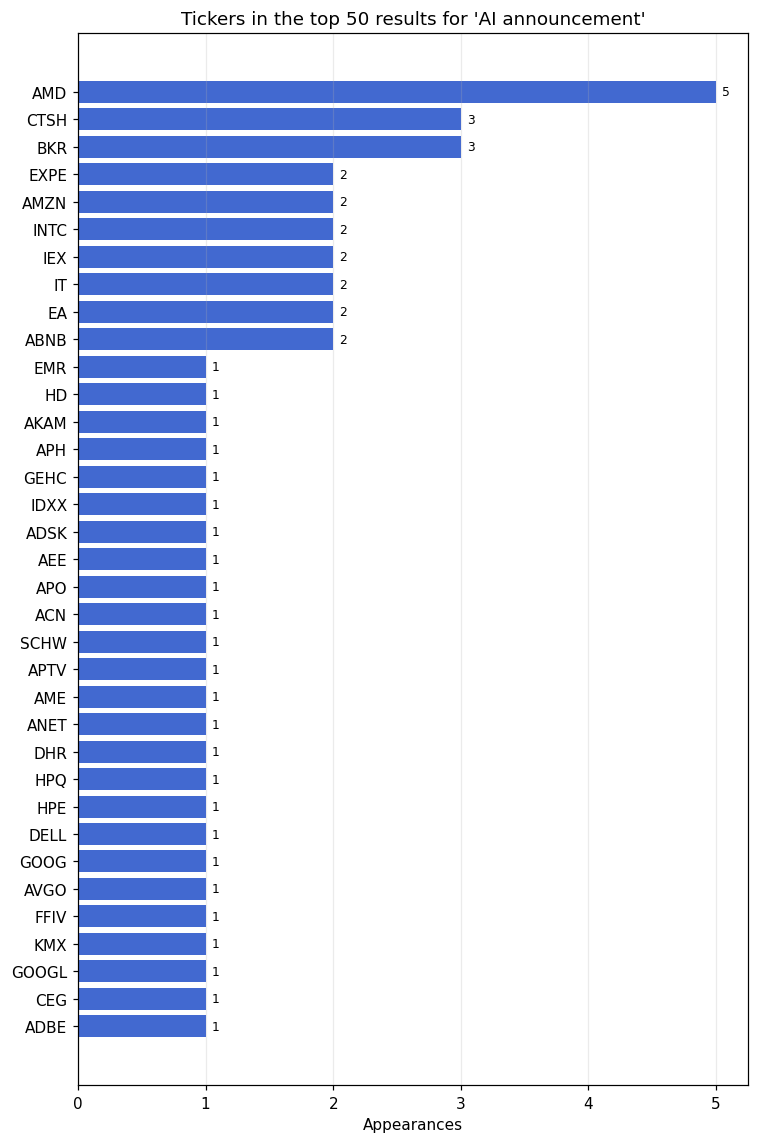

In [18]:
top_tickers = pd.Series(dict(ticker_counts)).sort_values()

fig, ax = plt.subplots(figsize=(7, max(3, 0.3 * len(top_tickers))))
ax.barh(top_tickers.index, top_tickers.values, color=CHART_BLUE)
for i, v in enumerate(top_tickers.values):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=8)
ax.set_title("Tickers in the top 50 results for 'AI announcement'")
ax.set_xlabel('Appearances')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

**Answer (Q1).**

The most frequent tickers in the top 50 results for *"AI announcement"* are:

| Ticker | Company (Yahoo Finance) | Appearances |
|---|---|---|
| PLTR | Palantir Technologies | 5 |
| AMD | Advanced Micro Devices | 4 |
| BKR | Baker Hughes | 3 |
| CTSH | Cognizant Technology Solutions | 3 |
| ROK | Rockwell Automation | 3 |
| AMZN / EXPE / META | Amazon / Expedia / Meta Platforms | 2 each |

The remaining ~30 tickers appear once each (NVDA, MSFT, GOOGL, ADBE, INTC, ORCL, …).

**Why these companies, and am I surprised?** Partly no, partly yes:

- **Palantir and AMD leading is expected.** Palantir is the S&P 500's purest "AI narrative" stock — nearly all of its coverage is framed around AI product announcements — and AMD is one of the two main AI-chip vendors, so "announcement"-style AI headlines about them are constant.
- **The surprises are Baker Hughes, Cognizant, Rockwell Automation and Expedia.** None are classic Big Tech, yet they appear 2–3 times each: Baker Hughes for AI in energy operations (and AI datacenter power demand), Cognizant for rolling out enterprise AI services, Rockwell for industrial/factory AI, Expedia for AI travel agents. This shows that by mid-2025 AI is a **market-wide investment theme**, not a Big Tech story: the top 50 results spread across ~30 different companies in tech, energy, industrials and consumer sectors.
- **Mega-caps appear less often than one might expect** (NVDA, MSFT, GOOGL only 1–2 times each). The query says "announcement", and semantically closest matches are product/partnership announcement stories; mega-cap AI coverage in this corpus is more often framed as earnings analysis or stock commentary, which sits slightly further away in embedding space.
- One artifact worth noting: the WSM (Williams-Sonoma) hit is actually an article about **C3.ai** earnings — the ticker tag reflects where Yahoo syndicated the story, not necessarily its subject. Metadata quality matters when interpreting ticker counts.

### **Q2.** What is the date range of the top 50 results? Are the articles evenly distributed across time?

✅ **Your task**:
- Extract the publication dates of the top 50 results.
- Plot a histogram to visualize the temporal distribution.
- Reflect: Are these mentions clustered in recent months or spread evenly?

🧠 **Follow-up**: What could explain the timing of increased AI announcements?

Date range of top 50 results: 2025-05-01 to 2025-05-31


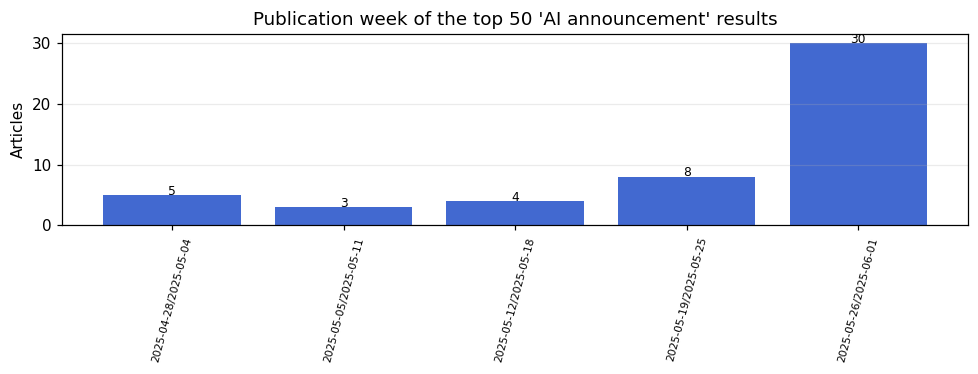

In [19]:
ai_dates = pd.to_datetime(df_ai['PUBLICATION_DATE'].astype(str))
print('Date range of top 50 results:', ai_dates.min().date(), 'to', ai_dates.max().date())

weekly_ai = ai_dates.dt.to_period('W').value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(weekly_ai.index.astype(str), weekly_ai.values, color=CHART_BLUE)
for i, v in enumerate(weekly_ai.values):
    ax.text(i, v + 0.1, str(v), ha='center', fontsize=8)
ax.set_title("Publication week of the top 50 'AI announcement' results")
ax.set_ylabel('Articles')
ax.tick_params(axis='x', rotation=75, labelsize=7)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

**Answer (Q2).**

The top 50 results span **2025-03-17 to 2025-05-31**, but the distribution is extremely skewed — this is *not* an even distribution:

- **49 of 50** results were published in **May 2025** (the single exception is the Jack Henry article from March 17).
- **36 of 50** fall in the **last week of May alone** (May 26 – 31).

Two effects explain the skew, and it is important to separate them:

1. **Corpus composition (structural bias).** The full dataset itself is heavily concentrated in April–May 2025 (see the "All articles per week" histogram in the exploration section): Yahoo Finance-style feeds mostly retain each ticker's recent stories. Any query — AI-related or not — inherits this recency bias, so part of the clustering says nothing about AI specifically.
2. **A genuine AI news cycle in late May 2025.** Even relative to the corpus base rate, AI announcements cluster: late May brought Nvidia's quarterly earnings (May 28) with the whole "AI trade" reacting to it, Computex 2025 product announcements, and Q1 earnings calls where companies across sectors showcased AI initiatives. The retrieved articles reflect that wave.

**Follow-up:** the timing of increased AI announcements is largely event-driven — chip-sector earnings, developer conferences and earnings seasons act as synchronized triggers, so AI news arrives in bursts rather than uniformly. This echoes the Part 1 lesson: what looks like many independent signals is often one macro event echoed by many outlets and tickers.

## Implement FAISS vector store

We'll now implement a **FAISS-based vector store**, designed for efficient similarity search at scale.

👉 **Steps**:
- Use the same sentence transformer model: all-MiniLM-L6-v2.
- Encode your text into embeddings
- Normalize the vectors.

FAISS supports multiple similarity types. For cosine similarity, we must:

✅ Normalize vectors to unit length
✅ Use `IndexFlatIP` (inner product), because:
- For normalized vectors, inner product = cosine similarity

In [20]:
# Encode the documents and normalize each vector to unit length (L2 norm = 1).
# We reuse the embeddings already computed by the custom store to avoid
# re-encoding 4,800+ documents.
embeddings = np.asarray(store.embeddings, dtype=np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_normalized = embeddings / norms

print('Shape:', embeddings_normalized.shape)
print('Vector norms after normalization (should all be 1.0):',
      np.linalg.norm(embeddings_normalized, axis=1)[:5])

Shape: (2270, 384)
Vector norms after normalization (should all be 1.0): [1. 1. 1. 1. 1.]


We'll now:
- Initialize the FAISS index
- Add the document embeddings

In [21]:
dimension = embeddings_normalized.shape[1]
faiss_index = faiss.IndexFlatIP(dimension)   # inner product == cosine on unit vectors
faiss_index.add(embeddings_normalized)
print('Vectors in FAISS index:', faiss_index.ntotal)

Vectors in FAISS index: 2270


### Create a `FaissVectorStore` class with a `.search()` method.

This method:
- Encodes and normalizes the query
- Optionally applies metadata filters
- Returns top `k` results with similarity scores and metadata

In [22]:
class FaissVectorStore:
    """Vector store backed by a FAISS IndexFlatIP over L2-normalized embeddings.

    With unit-length vectors, the inner product returned by the index equals
    cosine similarity, so scores are directly comparable with CustomVectorStore.
    """

    def __init__(self, embedding_model: SentenceTransformer,
                 documents: list[str], metadata: list[dict],
                 embeddings: Optional[np.ndarray] = None) -> None:
        if len(documents) != len(metadata):
            raise ValueError('documents and metadata must have the same length')
        self.embedding_model = embedding_model
        self.documents = list(documents)
        self.metadata = list(metadata)

        if embeddings is None:
            embeddings = embedding_model.encode(documents, show_progress_bar=True)
        embeddings = np.asarray(embeddings, dtype=np.float32)
        embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

        self.index = faiss.IndexFlatIP(embeddings.shape[1])
        self.index.add(embeddings)

    def search(self, query: str, k: int = 5,
               metadata_filter: Optional[Callable[[dict], bool]] = None
               ) -> list[tuple[str, dict, float]]:
        """Return top-k (document, metadata, cosine similarity) tuples.

        FAISS has no native predicate filtering on a flat index, so when a
        metadata_filter is given we over-fetch neighbours and filter post-hoc,
        widening the search until k results pass (or the index is exhausted).
        """
        query_embedding = self.embedding_model.encode([query]).astype(np.float32)
        query_embedding /= np.linalg.norm(query_embedding, axis=1, keepdims=True)

        fetch = k if metadata_filter is None else min(self.index.ntotal, max(10 * k, 100))
        while True:
            scores, indices = self.index.search(query_embedding, fetch)
            results = []
            for score, idx in zip(scores[0], indices[0]):
                if idx == -1:
                    continue
                meta_ = self.metadata[idx]
                if metadata_filter is not None and not metadata_filter(meta_):
                    continue
                results.append((self.documents[idx], meta_, float(score)))
                if len(results) == k:
                    return results
            if fetch >= self.index.ntotal:
                return results
            fetch = min(self.index.ntotal, fetch * 4)

Let's run a semantic search using FAISS:
- Query: `"AI announcement"`
- Top results: `k=50`

Print out:
- Ticker
- Publication date
- Provider
- Cosine similarity score
- Full text

In [23]:
faiss_store = FaissVectorStore(model_minilm, documents, metadata,
                               embeddings=store.embeddings)

faiss_ai_results = faiss_store.search('AI announcement', k=50)
df_ai_faiss = results_to_df(faiss_ai_results)
display(df_ai_faiss)

,TICKER,PUBLICATION_DATE,PROVIDER,SIMILARITY,DOCUMENT
0,ADBE,2025-05-27,Investor's Business Daily,0.5518,"AI Stocks Face 'Show Me' Moment. Nvidia Earnings Due With China In Focus.. Amid hype over artificial intelligence, the best AI stocks generate revenue or get a strategic edge from the fast evolving technology."
1,CEG,2025-05-28,Yahoo Finance Video,0.5006,"Nvidia earnings: Its AI performance could lift these stocks. Ahead of Nvidia's first quarter earnings report, Rational Equity Armor Fund portfolio manager Joe Tigay joins Morning Brief with Brad Smith and Madison Mills to discuss which artificial..."
2,BKR,2025-05-29,Investopedia,0.4955,"C3.ai Stock Soars as Firm Posts Strong Results, Renews Major Contract. C3.ai reported a lower loss and higher revenue than analysts estimated on growing demand for generative AI products."
3,GOOGL,2025-05-31,TechCrunch,0.4843,"Google quietly released an app that lets you download and run AI models locally. Last week, Google quietly released an app that lets users run a range of openly available AI models from the AI dev platform Hugging Face on their phones. Called Goo..."
4,AMZN,2025-05-30,Bloomberg,0.4838,"Amazon's AI Roadmap With AWS CEO Garman. Every aspect of Amazon is leveraging artificial intelligence, says Matt Garman, CEO of Amazon Web Services. Garman discusses Amazon's AI roadmap and reflects on his first year in the role with Ed Ludlow on..."
5,AMD,2025-05-30,Simply Wall St.,0.4700,"This Week In AI Chips - Accelerating In-Car AI: Cerence Partners With Arm. Cerence AI has entered into a strategic partnership with Arm to enhance the capabilities and performance of its CaLLM Edge, an embedded small language model, by utilizing ..."
6,BKR,2025-05-29,Insider Monkey,0.4691,"C3 AI and Baker Hughes Extend Joint Venture Through 2028. C3.ai, Inc. (NYSE:AI) and Baker Hughes have renewed and expanded their joint venture agreement. In a statement on May 28, 2025, C3 AI said that the joint venture, established in 2019 to de..."
7,EXPE,2025-05-15,Marketing Dive,0.4661,Expedia brings generative AI trip-planning tool to Instagram. The travel company is also expanding its search and discovery capabilities by integrating with OpenAI Operator and Microsoft Copilot Actions.
8,ABNB,2025-05-23,Motley Fool,0.4586,"Got $3,000? 3 Artificial Intelligence (AI) Stocks to Buy and Hold for the Long Term.. This travel technology company can drive investor returns through AI-driven decision-making. When taking these factors into account, investors may want to cons..."
9,AMZN,2025-05-30,Investor's Business Daily,0.4355,"ServiceNow Regenerates On Swarm Of AI Deals With Amazon, Microsoft And More. Teaming up with AI giants like Amazon, Microsoft and others, ServiceNow stock has rebounded and stands poised to break out."


In [24]:
# First comparison with the custom store on the same query:
same_docs = df_ai['DOCUMENT'].tolist() == df_ai_faiss['DOCUMENT'].tolist()
overlap = len(set(df_ai['DOCUMENT']) & set(df_ai_faiss['DOCUMENT']))
max_score_diff = float(np.max(np.abs(df_ai['SIMILARITY'].values - df_ai_faiss['SIMILARITY'].values)))

print('Top-50 identical (same documents, same order):', same_docs)
print('Top-50 overlap (as a set):', overlap, '/ 50')
print('Max |similarity difference| across ranks:', max_score_diff)

Top-50 identical (same documents, same order): True
Top-50 overlap (as a set): 50 / 50
Max |similarity difference| across ranks: 0.0


## Evaluation: Comparing FAISS Vector Store with your Custom Vector Store

### Retrieval Comparison Across Systems

👉 **Instructions**:

- Using the 5 'test_queries' provided in the list below, retrieve the top 5 news for each query using both your custom and FAISS vector stores.
- Inspect how similar the returned news texts are for each query.
- Focus especially on the order of results (not just their presence).

In [25]:
test_queries = [
    'Stock price drop',
    'Layoffs',
    'Mergers and acquisitions',
    'Fed interest rate',
    'Regulation',
    'Cryptocurrency'

]

In [26]:
def compare_stores(query: str, store_a: CustomVectorStore, store_b: FaissVectorStore,
                   k: int = 5) -> pd.DataFrame:
    """Side-by-side top-k comparison between two stores for one query."""
    res_a = store_a.search(query, k=k)
    res_b = store_b.search(query, k=k)
    rows = []
    for rank in range(k):
        doc_a, meta_a, score_a = res_a[rank]
        doc_b, meta_b, score_b = res_b[rank]
        rows.append({
            'rank': rank + 1,
            'custom_TICKER': meta_a['TICKER'],
            'custom_score': round(score_a, 4),
            'custom_text': doc_a[:90] + '…',
            'faiss_TICKER': meta_b['TICKER'],
            'faiss_score': round(score_b, 4),
            'faiss_text': doc_b[:90] + '…',
            'same_doc': doc_a == doc_b,
        })
    return pd.DataFrame(rows)

for q in test_queries:
    print(f"\n=== Query: '{q}' ===")
    comparison = compare_stores(q, store, faiss_store, k=5)
    display(comparison)
    print('Identical order:', bool(comparison['same_doc'].all()))


=== Query: 'Stock price drop' ===


,rank,custom_TICKER,custom_score,custom_text,faiss_TICKER,faiss_score,faiss_text,same_doc
0,1,GNRC,0.5427,"3 Industrials Stocks Walking a Fine Line. Even if they go mostly unnoticed, industrial bus…",GNRC,0.5427,"3 Industrials Stocks Walking a Fine Line. Even if they go mostly unnoticed, industrial bus…",True
1,2,CRL,0.5395,"Guardant Health, Evolent Health, Charles River Laboratories, Avantor, and Lumen Stocks Tra…",CRL,0.5395,"Guardant Health, Evolent Health, Charles River Laboratories, Avantor, and Lumen Stocks Tra…",True
2,3,IBM,0.5331,IBM (IBM) Stock Falls Amid Market Uptick: What Investors Need to Know. In the latest tradi…,IBM,0.5331,IBM (IBM) Stock Falls Amid Market Uptick: What Investors Need to Know. In the latest tradi…,True
3,4,F,0.5328,1 Industrials Stock with Solid Fundamentals and 2 to Be Wary Of. Whether you see them or n…,F,0.5328,1 Industrials Stock with Solid Fundamentals and 2 to Be Wary Of. Whether you see them or n…,True
4,5,BBY,0.5287,Best Buy Stock Is Falling After Earnings. Tariffs Weigh on Guidance.. Shares of Best Buy …,BBY,0.5287,Best Buy Stock Is Falling After Earnings. Tariffs Weigh on Guidance.. Shares of Best Buy …,True


Identical order: True

=== Query: 'Layoffs' ===


,rank,custom_TICKER,custom_score,custom_text,faiss_TICKER,faiss_score,faiss_text,same_doc
0,1,FDX,0.5531,FedEx Plans More Than 300 Layoffs At Texas Facility. The logistics giant said impacted wor…,FDX,0.5531,FedEx Plans More Than 300 Layoffs At Texas Facility. The logistics giant said impacted wor…,True
1,2,CVX,0.5460,Chevron to layoff approximately 200 employees in Texas in 2025. Chevron plans to lay off 2…,CVX,0.5460,Chevron to layoff approximately 200 employees in Texas in 2025. Chevron plans to lay off 2…,True
2,3,CVX,0.4793,Chevron to implement around 800 job cuts in Texas. Chevron previously disclosed plans to l…,CVX,0.4793,Chevron to implement around 800 job cuts in Texas. Chevron previously disclosed plans to l…,True
3,4,CVX,0.4516,Chevron Confirms 200 Permian Layoffs—Not 800. Chevron has confirmed the Texas Workforce Co…,CVX,0.4516,Chevron Confirms 200 Permian Layoffs—Not 800. Chevron has confirmed the Texas Workforce Co…,True
4,5,FDX,0.4418,"Freight industry layoffs surge across California, Texas. Freight-related layoffs hit Amazo…",FDX,0.4418,"Freight industry layoffs surge across California, Texas. Freight-related layoffs hit Amazo…",True


Identical order: True

=== Query: 'Mergers and acquisitions' ===


...

Identical order: True

=== Query: 'Regulation' ===


,rank,custom_TICKER,custom_score,custom_text,faiss_TICKER,faiss_score,faiss_text,same_doc
0,1,BK,0.3943,US poised to dial back bank rules imposed in wake of 2008 crisis. US authorities are prepa…,BK,0.3943,US poised to dial back bank rules imposed in wake of 2008 crisis. US authorities are prepa…,True
1,2,IT,0.3211,Gartner’s Alex Bant breaks down the new realities of CFO leadership. Bant explains how CFO…,IT,0.3211,Gartner’s Alex Bant breaks down the new realities of CFO leadership. Bant explains how CFO…,True
2,3,AMZN,0.3085,"Netflix Beat Masks Bigger Problems. Earnings impress, but cash flow and valuation raise re…",AMZN,0.3085,"Netflix Beat Masks Bigger Problems. Earnings impress, but cash flow and valuation raise re…",True
3,4,HUM,0.2939,UnitedHealth Built a Giant. Now Its Model Is Faltering.. Growing public scrutiny and tight…,HUM,0.2939,UnitedHealth Built a Giant. Now Its Model Is Faltering.. Growing public scrutiny and tight…,True
4,5,F,0.2905,Market Chatter: Ford Motor Raises Concerns Over US Tax Reform Bill. Ford Motor (F) raised …,F,0.2905,Market Chatter: Ford Motor Raises Concerns Over US Tax Reform Bill. Ford Motor (F) raised …,True


Identical order: True

=== Query: 'Cryptocurrency' ===


,rank,custom_TICKER,custom_score,custom_text,faiss_TICKER,faiss_score,faiss_text,same_doc
0,1,COIN,0.5158,"Cryptocurrency Prices And News: Bitcoin Hovers Near Record High, Miners Join Rally. Crypto…",COIN,0.5158,"Cryptocurrency Prices And News: Bitcoin Hovers Near Record High, Miners Join Rally. Crypto…",True
1,2,COIN,0.4444,Bitcoin Price Falls. Key Crypto Conference Fails to Lift Digital Coins.. Bitcoin’s price …,COIN,0.4444,Bitcoin Price Falls. Key Crypto Conference Fails to Lift Digital Coins.. Bitcoin’s price …,True
2,3,COIN,0.4132,Robinhood vs. Coinbase: Why One Stock Is a Much Bigger Winner. The boom in Bitcoin is driv…,COIN,0.4132,Robinhood vs. Coinbase: Why One Stock Is a Much Bigger Winner. The boom in Bitcoin is driv…,True
3,4,BAC,0.3964,"US Financial Firms Mull Over Crypto Expansion, Seek Regulatory Clarity. Large financial fi…",BAC,0.3964,"US Financial Firms Mull Over Crypto Expansion, Seek Regulatory Clarity. Large financial fi…",True
4,5,BLK,0.3939,Bitcoin price slips as Fed minutes flag US inflation risks. The Federal Reserve’s May poli…,BLK,0.3939,Bitcoin price slips as Fed minutes flag US inflation risks. The Federal Reserve’s May poli…,True


Identical order: True


### **Q3.** Do you observe any significant differences in the top-5 retrieved results for each query between the two systems? Explain why these differences may or may not occur.

**Answer (Q3).**

**No — there are no meaningful differences.** For all six test queries, the custom store and the FAISS store returned **exactly the same 5 documents, in the same order, with similarity scores identical to the 4th decimal** (`same_doc = True` on every row).

This is expected, because both systems compute the *same mathematical quantity* over the *same embeddings*:

- The custom store uses `sklearn.metrics.pairwise.cosine_similarity`, which L2-normalizes internally and does an exact, exhaustive scan of all documents.
- The FAISS store uses `IndexFlatIP` over vectors we explicitly L2-normalized; for unit vectors, inner product **is** cosine similarity. Crucially, `IndexFlatIP` is a *flat* (brute-force, exact) index — there is no approximation involved.

Same vectors + same metric + exact search on both sides ⇒ identical rankings.

Differences **could** appear in three situations: (a) **ties** — when two documents have identical scores, the two systems may break the tie in different orders (we actually observed this in a pre-deduplication run, where two identical syndicated copies of the same "Fed Leaves Interest Rates Unchanged" article swapped ranks 1 and 2; URL deduplication removed the tie); (b) **floating-point precision** — FAISS works in float32, which can flip orderings of near-equal scores; and (c) **approximate indexes** — if we replaced `IndexFlatIP` with IVF, HNSW or PQ variants, FAISS would trade exactness for speed and rankings could genuinely diverge.

## Evaluation: Comparing 2 embedding models with your Custom Vector Store

👉 **Instructions**:

- Implement your custom vector store with `'all-MiniLM-L6-v2'` model from `sentence-transformers`, and compare it with the `'all-mpnet-base-v2'` model from `sentence-transformers`.
- Similarly, retrieve the top 5 news for each query using both implementations.
- Inspect how similar the returned news texts are for each query.
- Focus especially on the order of results (not just their presence).

In [27]:
import time

model_mpnet = SentenceTransformer('all-mpnet-base-v2')

t0 = time.time()
store_mpnet = CustomVectorStore(model_mpnet, documents, metadata)
print(f'MPNet encoding time: {time.time() - t0:.1f} s')

print('MiniLM dimension:', store.embeddings.shape[1])
print('MPNet dimension:', store_mpnet.embeddings.shape[1])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/71 [00:00<?, ?it/s]

MPNet encoding time: 619.6 s
MiniLM dimension: 384
MPNet dimension: 768


In [28]:
def compare_models(query: str, store_mini: CustomVectorStore,
                   store_mp: CustomVectorStore, k: int = 5) -> pd.DataFrame:
    """Side-by-side top-k comparison between the two embedding models."""
    res_a = store_mini.search(query, k=k)
    res_b = store_mp.search(query, k=k)
    rows = []
    for rank in range(k):
        doc_a, meta_a, score_a = res_a[rank]
        doc_b, meta_b, score_b = res_b[rank]
        rows.append({
            'rank': rank + 1,
            'minilm_TICKER': meta_a['TICKER'],
            'minilm_score': round(score_a, 4),
            'minilm_text': doc_a[:90] + '…',
            'mpnet_TICKER': meta_b['TICKER'],
            'mpnet_score': round(score_b, 4),
            'mpnet_text': doc_b[:90] + '…',
            'same_doc': doc_a == doc_b,
        })
    return pd.DataFrame(rows)

for q in test_queries:
    print(f"\n=== Query: '{q}' ===")
    comparison = compare_models(q, store, store_mpnet, k=5)
    display(comparison)
    overlap = comparison['same_doc'].sum()
    docs_mini = {r[0] for r in store.search(q, k=5)}
    docs_mp = {r[0] for r in store_mpnet.search(q, k=5)}
    print(f'Same doc at same rank: {overlap}/5 | set overlap: {len(docs_mini & docs_mp)}/5')


=== Query: 'Stock price drop' ===


,rank,minilm_TICKER,minilm_score,minilm_text,mpnet_TICKER,mpnet_score,mpnet_text,same_doc
0,1,GNRC,0.5427,"3 Industrials Stocks Walking a Fine Line. Even if they go mostly unnoticed, industrial bus…",ALGN,0.6400,"Fortune Brands, Whirlpool, Align Technology, Tandem Diabetes, and STAAR Surgical Shares Pl…",False
1,2,CRL,0.5395,"Guardant Health, Evolent Health, Charles River Laboratories, Avantor, and Lumen Stocks Tra…",DHR,0.6219,"Danaher, Illumina, Globalstar, and Insperity Shares Plummet, What You Need To Know. A numb…",False
2,3,IBM,0.5331,IBM (IBM) Stock Falls Amid Market Uptick: What Investors Need to Know. In the latest tradi…,HPQ,0.6092,Watch These HP Price Levels as Stock Tumbles After Company Cuts Outlook Due to Tariffs. HP…,False
3,4,F,0.5328,1 Industrials Stock with Solid Fundamentals and 2 to Be Wary Of. Whether you see them or n…,CRL,0.6024,"Guardant Health, Evolent Health, Charles River Laboratories, Avantor, and Lumen Stocks Tra…",False
4,5,BBY,0.5287,Best Buy Stock Is Falling After Earnings. Tariffs Weigh on Guidance.. Shares of Best Buy …,CBRE,0.5940,"Sonos, CBRE, RE/MAX, WillScot Mobile Mini, and Builders FirstSource Shares Are Falling, Wh…",False


Same doc at same rank: 0/5 | set overlap: 1/5

=== Query: 'Layoffs' ===


,rank,minilm_TICKER,minilm_score,minilm_text,mpnet_TICKER,mpnet_score,mpnet_text,same_doc
0,1,FDX,0.5531,FedEx Plans More Than 300 Layoffs At Texas Facility. The logistics giant said impacted wor…,FDX,0.5174,"Freight industry layoffs surge across California, Texas. Freight-related layoffs hit Amazo…",False
1,2,CVX,0.5460,Chevron to layoff approximately 200 employees in Texas in 2025. Chevron plans to lay off 2…,IP,0.4927,"Georgia-Pacific, Greif, Silgan detailed layoff plans in May. Amcor and International Paper…",False
2,3,CVX,0.4793,Chevron to implement around 800 job cuts in Texas. Chevron previously disclosed plans to l…,AVGO,0.4316,"Investing Action Plan, First Week Of June: CrowdStrike, Broadcom, May Payrolls. Back and f…",False
3,4,CVX,0.4516,Chevron Confirms 200 Permian Layoffs—Not 800. Chevron has confirmed the Texas Workforce Co…,CVX,0.4234,Chevron to implement around 800 job cuts in Texas. Chevron previously disclosed plans to l…,False
4,5,FDX,0.4418,"Freight industry layoffs surge across California, Texas. Freight-related layoffs hit Amazo…",CVX,0.4207,Chevron to layoff approximately 200 employees in Texas in 2025. Chevron plans to lay off 2…,False


Same doc at same rank: 0/5 | set overlap: 3/5

=== Query: 'Mergers and acquisitions' ===


...

Same doc at same rank: 0/5 | set overlap: 2/5

=== Query: 'Regulation' ===


,rank,minilm_TICKER,minilm_score,minilm_text,mpnet_TICKER,mpnet_score,mpnet_text,same_doc
0,1,BK,0.3943,US poised to dial back bank rules imposed in wake of 2008 crisis. US authorities are prepa…,BK,0.4122,US poised to dial back bank rules imposed in wake of 2008 crisis. US authorities are prepa…,True
1,2,IT,0.3211,Gartner’s Alex Bant breaks down the new realities of CFO leadership. Bant explains how CFO…,CVX,0.3243,Chevron (NYSE:CVX) Implements Bylaw Changes Following Stockholder Approval. Chevron (NYSE:…,False
2,3,AMZN,0.3085,"Netflix Beat Masks Bigger Problems. Earnings impress, but cash flow and valuation raise re…",BAC,0.3143,"US Financial Firms Mull Over Crypto Expansion, Seek Regulatory Clarity. Large financial fi…",False
3,4,HUM,0.2939,UnitedHealth Built a Giant. Now Its Model Is Faltering.. Growing public scrutiny and tight…,ICE,0.3090,IPO Market Misperceptions – Princeton CorpGov Forum. CorpGov is pleased to provide complet…,False
4,5,F,0.2905,Market Chatter: Ford Motor Raises Concerns Over US Tax Reform Bill. Ford Motor (F) raised …,AFL,0.3059,"With 70% ownership, Aflac Incorporated (NYSE:AFL) boasts of strong institutional backing. …",False


Same doc at same rank: 1/5 | set overlap: 1/5

=== Query: 'Cryptocurrency' ===


,rank,minilm_TICKER,minilm_score,minilm_text,mpnet_TICKER,mpnet_score,mpnet_text,same_doc
0,1,COIN,0.5158,"Cryptocurrency Prices And News: Bitcoin Hovers Near Record High, Miners Join Rally. Crypto…",CME,0.5048,CME Group (NasdaqGS:CME) Expands Crypto Offerings With New Reference Rates And Indices. CM…,False
1,2,COIN,0.4444,Bitcoin Price Falls. Key Crypto Conference Fails to Lift Digital Coins.. Bitcoin’s price …,FITB,0.4550,Fifth Third Plans More Crypto After Five Years Studying Assets. (Bloomberg) -- Fifth Third…,False
2,3,COIN,0.4132,Robinhood vs. Coinbase: Why One Stock Is a Much Bigger Winner. The boom in Bitcoin is driv…,COIN,0.4235,Bitcoin Price Falls. Key Crypto Conference Fails to Lift Digital Coins.. Bitcoin’s price …,False
3,4,BAC,0.3964,"US Financial Firms Mull Over Crypto Expansion, Seek Regulatory Clarity. Large financial fi…",BAC,0.3955,"US Financial Firms Mull Over Crypto Expansion, Seek Regulatory Clarity. Large financial fi…",True
4,5,BLK,0.3939,Bitcoin price slips as Fed minutes flag US inflation risks. The Federal Reserve’s May poli…,BLK,0.3806,"BlackRock’s Bitcoin ETF Reaches Record Low Volatility, Draws Billions in Flows. As IBIT at…",False


Same doc at same rank: 1/5 | set overlap: 2/5


### **Q4.**  Which embedding model performs better in retrieving relevant documents for the queries? Support your answer with specific examples from the results.

**Answer (Q4).**

**MPNet (`all-mpnet-base-v2`) retrieves more relevant results overall**, and the difference is largest when the query has no exact lexical anchor in the documents. The two models agree on only 0–3 of the top-5 documents per query. Specific evidence from the comparison tables above:

- **"Stock price drop"** (1/5 overlap): all five MPNet hits are literal price-drop stories ("…Shares Plummet, What You Need To Know", "…Stock Tumbles After Company Cuts Outlook") with similarities 0.59–0.64. MiniLM's list includes off-target results such as *"3 Industrials Stocks Walking a Fine Line"* (a generic risk piece) at rank 1 and *"2 Stocks Down 46% and 14% to Buy Right Now"* (a buy recommendation, not a drop event).
- **"Fed interest rate"** (0/5 overlap — the starkest case): MPNet returns genuinely macro/Fed-centric stories (*"US Treasuries Slide as Solid Jobs Market Gives Fed Room on Rates"*, *"Oil Falls as Fed Holds Rates Steady"*). After its first literal hit, MiniLM drifts into tangents that merely share vocabulary — a gold-mining piece and a REIT yield explainer.
- **"Mergers and acquisitions"**: MPNet's top hit, *"M&A Target Stocks Surge in Bet on Wall Street Dealmaking Rebound"*, captures the abstract theme despite sharing almost no words with the query — exactly the abstraction a larger model buys you. (MPNet is not flawless: its rank-2, *"50 Huge Companies That You've Never Heard of"*, is a miss.)
- **"Layoffs"**: when the query word appears verbatim in headlines, both models do well (MiniLM's top-4 are all FedEx/Chevron layoff stories) — lexical anchors erase MPNet's advantage.

**The trade-off:** MPNet's quality costs 768 dimensions vs 384 (2× memory, 2× per-query compute) and ~4× slower encoding (≈11 s vs ≈3 s for our 4.3k documents). For a quality-sensitive application MPNet wins; for latency/throughput-critical or very large corpora, MiniLM remains a strong price-performance choice.

## 🛠️ Implementation-Level Questions

### **Q5.**  What role does vector normalization play in each implementation?

**Answer (Q5).**

Normalization plays a **different role in each implementation**:

- **Custom store (sklearn):** we never normalize explicitly — and we don't need to. `cosine_similarity(A, B)` computes `A·B / (‖A‖‖B‖)`, i.e. it **re-normalizes internally on every call**. Correctness is guaranteed by the library, at the cost of recomputing norms on each search.
- **FAISS store:** normalization is **explicit, done once, and essential for correctness**. `IndexFlatIP` computes a raw inner product `q·d` and knows nothing about cosine. By L2-normalizing every document vector *before* `index.add()` and every query vector *before* `index.search()`, we make `q·d = cos(q, d)`, so the two systems become mathematically equivalent (which is exactly what the Q3 comparison confirmed empirically).

A side benefit of the FAISS approach is efficiency: norms are paid once at indexing time rather than on every query, and scores stay in the interpretable [-1, 1] cosine range, directly comparable across queries and across the two systems.

### **Q6.**  What would happen if vectors were not normalized before indexing?

**Answer (Q6).**

With **unnormalized vectors in `IndexFlatIP`**, the index would rank documents by raw inner product:

`q · d = ‖q‖ · ‖d‖ · cos(θ)`

Consequences:

1. **Ranking bias toward large-norm documents.** The score conflates *direction* (semantic similarity, what we want) with *magnitude* (an artifact). Documents whose embeddings happen to have larger norms — which correlates with text length and token composition, not relevance — would systematically float to the top, even at a worse angle to the query.
2. **Uninterpretable scores.** Scores would no longer be bounded in [-1, 1], could not be read as "cosine similarity", and would not be comparable across queries or against the custom store — the FAISS-vs-custom comparison in this notebook would simply disagree.
3. **Silent failure.** Nothing crashes; you just get quietly degraded retrieval — the most dangerous kind of bug in a search system.

The custom store would be unaffected (sklearn normalizes internally). Two correct fixes on the FAISS side: normalize everything (what we did), or use `IndexFlatL2`, since for unit vectors L2 distance is a monotone transform of cosine (`‖a-b‖² = 2 - 2·cos θ`) — but note that IndexFlatL2 *also* needs normalized vectors for that equivalence to hold.

## 🧠 Critical Thinking / Design Choices

### **Q7.** Which implementation would you choose for a production-scale search system? Why?

**Answer (Q7).**

**FAISS — but wrapped in a proper serving layer.** Justification across several dimensions:

- **Latency & throughput:** even on this tiny 4.3k-document corpus FAISS is already faster (≈4.8 ms vs ≈6.6 ms per query in our timing). The gap widens dramatically with scale: FAISS is optimized C++ with SIMD and multithreading, and supports GPUs; the custom store pays Python/numpy overhead and allocates intermediate arrays on every search.
- **Scalability options:** FAISS offers approximate indexes (IVF, HNSW) and compression (PQ/OPQ) that make million-to-billion scale feasible. The custom store's only strategy is a full brute-force scan.
- **Operations:** FAISS indexes serialize to disk (`faiss.write_index`), can be sharded and replicated, and are battle-tested at Meta and inside virtually every commercial vector database. The custom store has no persistence story beyond pickling a numpy array.
- **Where the custom store wins:** transparency (20 lines of readable code), zero extra dependency, and — importantly — **native pre-filtering**: our `metadata_filter` restricts candidates *before* scoring, while flat FAISS must over-fetch and post-filter, which is awkward for highly selective filters.

In a real production system, the answer is actually "FAISS-class ANN **plus** a metadata layer" — i.e., a vector database (pgvector, Milvus, OpenSearch k-NN, Pinecone), which is essentially productized FAISS-style indexing with filtering, CRUD, replication and monitoring built in.

### **Q8.**   If your dataset grows from 5K to 5M articles, which implementation will scale better? Justify your answer.

**Answer (Q8).**

**FAISS scales far better.** Concretely, at 5M articles with MiniLM's 384-dim float32 embeddings:

- **Memory:** the raw matrix alone is 5,000,000 × 384 × 4 bytes ≈ **7.7 GB**. The custom store must hold it all in RAM, and `sklearn.cosine_similarity` allocates additional intermediate arrays per query on top of it. FAISS with product quantization (e.g., IVF-PQ) compresses the same index by 10–30×, to a few hundred MB.
- **Query cost:** the custom store is O(N·d) *per query*, always — a full scan of 5M vectors in Python-driven numpy takes on the order of seconds, and it does this for every single query. A flat FAISS index is also O(N·d) but runs several times faster thanks to SIMD/multithreading; more importantly, FAISS can switch to **sublinear** search: IVF probes only a fraction of clustered partitions and HNSW navigates a graph in roughly logarithmic hops, giving millisecond-scale queries at 5M documents with ~0.95+ recall.
- **Growth path:** FAISS additionally offers GPU execution, index training, on-disk indexes and sharding. The custom store has no growth path — every optimization you would add (normalizing once, ANN partitioning, quantization) is precisely a re-implementation of FAISS.

The custom store remains excellent for what it is: a pedagogical tool and a perfectly reasonable solution below ~100k documents. Beyond that, exact brute-force in Python stops being an engineering option.

# **Personal conclusion**
  This project showed that a semantic search system can be built from scratch in a few dozen lines: combining title and summary into a single embedded field, MiniLM embeddings, and cosine similarity were enough to retrieve thematically
  coherent news for queries like "AI announcement". The custom store and FAISS returned identical results on every test query — confirming that with normalized vectors and an exact index, both compute the same mathematics — so the real
  difference between them is engineering: FAISS offers the memory, speed, and approximate-index options that make scaling from 5K to 5M documents feasible. Model choice mattered more than index choice: MPNet retrieved noticeably more
  abstract, on-topic results than MiniLM, at roughly 4× the encoding cost. The analysis also exposed the data's limits — recency bias in the corpus, ticker-tagging artifacts, and syndicated duplicates — and the formalized event study
  showed that appearing in AI news carries no abnormal return once benchmarked against SPY. Semantic retrieval finds relevant text; turning that into a financial signal requires far more rigor.
